In [1]:
import sys
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F

# still do preprocessing in scipy
import scipy.sparse as sp

from importlib import reload

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/splicing-VAE')
import VAE_model
reload(VAE_model)

import matplotlib.pyplot as plt

In [2]:
# review https://sebastiancallh.github.io/post/vae-anatomy/

In [3]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [5]:
device

device(type='cuda')

In [185]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'
#input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/'

# mouse muscle 
#input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/"
#input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte'] #ignoring Bergmann_glial_cell since very few cells

#cell_types = ["Mammary_Gland_basal_cell", "Mammary_Gland_luminal_epithelial_cell_of_mammary_gland", "Mammary_Gland_stromal_cell"]
#print(cell_types)

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes", celltypes=cell_types) 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
Removing singletons ...
Number of junctions before removing singletons:  16190
Number of junctions after removing singletons:  16187
The number of unique cell types in the data is:  8
The number of unique cells in the data is:  7816
The number of unique junctions in the data is:  16188
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
The number of junctions in the data is:  15926
The number of cells in the data is:  7816
The number of cell types in the data

In [186]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


In [187]:
cell_ids_conversion.cell_type.value_counts()

Brain_Myeloid_microglial_cell                       4394
Brain_Non-Myeloid_oligodendrocyte                   1574
Brain_Non-Myeloid_endothelial_cell                   715
Brain_Non-Myeloid_astrocyte                          432
Brain_Non-Myeloid_neuron                             281
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     203
Brain_Non-Myeloid_brain_pericyte                     156
Brain_Myeloid_macrophage                              61
Name: cell_type, dtype: int64

In [188]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [189]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [190]:
# set up sparse tensor for junction counts 
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)

# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)

# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [191]:
# set up sparse tensor for cluster counts
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [192]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [193]:
# check if train_loader is on cuda
torch.cuda.is_available()

True

In [194]:
# Example usage:
junction_tensor, intron_tensor = y_tensor, total_counts_tensor

In [195]:
y_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  7815,  7815,  7815],
                       [    0,     1,     2,  ..., 15886, 15900, 15918]]),
       values=tensor([11., 10., 16.,  ...,  0.,  0.,  0.]),
       size=(7816, 15926), nnz=10545293, layout=torch.sparse_coo)

In [196]:
total_counts_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  7815,  7815,  7815],
                       [    0,     1,     2,  ..., 15886, 15900, 15918]]),
       values=tensor([21., 21., 16.,  ..., 31., 29., 31.]),
       size=(7816, 15926), nnz=10545293, layout=torch.sparse_coo)

<Axes: >

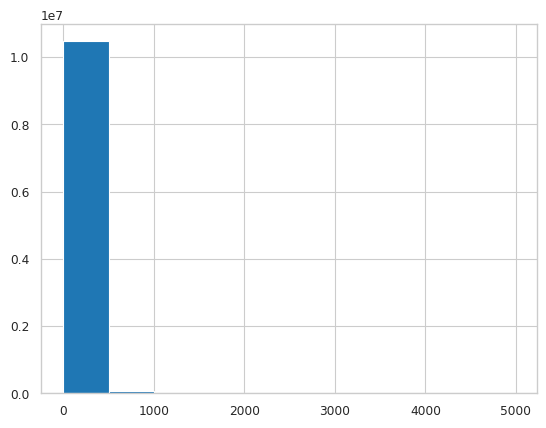

In [197]:
final_data.cluster_count.hist()

In [198]:
5056385 / (2405*20898)

0.10060517683256702

In [199]:
# input --> junction usage ratios (PSI)
# output --> junction counts via inferred PSI and total counts

In [200]:
reload(VAE_model)
from VAE_model import *

In [440]:
# Configuration
LEARNING_RATE = 0.001
NUM_EPOCHS = 300
BATCH_SIZE = 512
USE_CUDA = torch.cuda.is_available()
print(USE_CUDA)

INPUT_DIM = junction_tensor.shape[1]
HIDDEN_DIMS = [128, 64]  # Example dimensions, adjust as needed
Z_DIM = 14  # Example dimension, adjust as needed
OUTPUT_DIM = INPUT_DIM  # Assuming output dimension matches input
perc_train = 0.7

True


In [441]:
train_loader, test_loader, full_dat = setup_data_loaders(junction_tensor, intron_tensor, BATCH_SIZE, USE_CUDA, perc_train)

model = VAE(INPUT_DIM, HIDDEN_DIMS, Z_DIM, OUTPUT_DIM)
model.train()

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

Percentage of data used for training:  0.7


In [442]:
# best validation loss 
best_val_loss = float('inf')
max_patience = 3
best_epoch = 0
train_losses = []
val_losses = []

# Training Loop
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}")
    avg_train_loss = train(model, train_loader, optimizer, epoch)
    avg_val_loss = evaluate(model, test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        patience = max_patience
    else:
        patience -= 1
        if patience == 0:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1
====> Epoch: 1 Average training loss: 0.0477
====> Evaluation set average loss: 0.0177
Epoch 2
====> Epoch: 2 Average training loss: 0.0138
====> Evaluation set average loss: 0.0106
Epoch 3
====> Epoch: 3 Average training loss: 0.0088
====> Evaluation set average loss: 0.0077
Epoch 4
====> Epoch: 4 Average training loss: 0.0066
====> Evaluation set average loss: 0.0065
Epoch 5
====> Epoch: 5 Average training loss: 0.0056
====> Evaluation set average loss: 0.0058
Epoch 6
====> Epoch: 6 Average training loss: 0.0050
====> Evaluation set average loss: 0.0054
Epoch 7
====> Epoch: 7 Average training loss: 0.0047
====> Evaluation set average loss: 0.0052
Epoch 8
====> Epoch: 8 Average training loss: 0.0045
====> Evaluation set average loss: 0.0050
Epoch 9
====> Epoch: 9 Average training loss: 0.0043
====> Evaluation set average loss: 0.0049
Epoch 10
====> Epoch: 10 Average training loss: 0.0042
====> Evaluation set average loss: 0.0049
Epoch 11
====> Epoch: 11 Average training loss: 

In [443]:
# find min values in val_losses list 
min_val_loss = min(val_losses)
min_train_loss = min(train_losses)
print(f"Min validation loss: {min_val_loss}")
print(f"Min training loss: {min_train_loss}")

Min validation loss: 0.004408224610123299
Min training loss: 0.003844622937270262


In [444]:
# why is it when i increase latent space z dim, the validation loss is smaller than training loss?
# if i keep it at 20, the training loss is smaller than validation loss which is expected

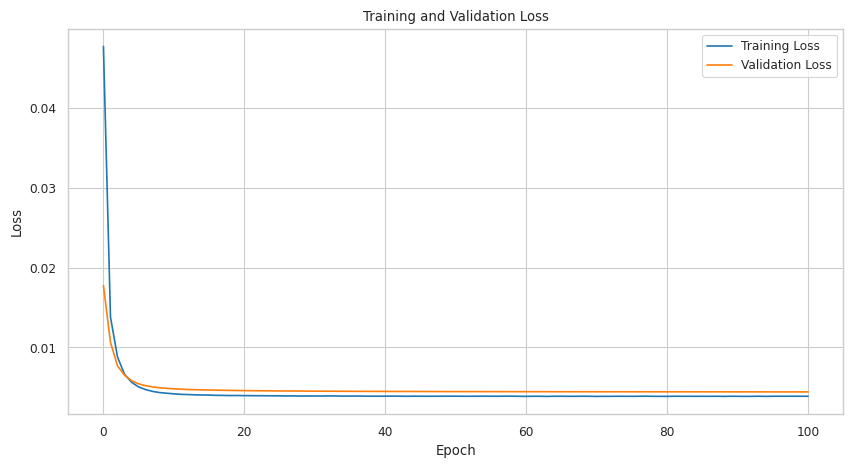

In [445]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [446]:
reload(VAE_model)
from VAE_model import *

### Obtain Z latent space 

In [447]:
model.eval()  # Set the model to evaluation mode
latent_variables = []
with torch.no_grad():
    for data in full_dat:
        inputs = data['proportions'].to(device)  # Ensure data is on the correct device
        z = model.extract_latent_variables(inputs, apply_noise=True)  # Apply_noise=False to get the mean of the latent space
        latent_variables.append(z.cpu().numpy())  # Move z to CPU and convert to numpy

latent_variables = np.concatenate(latent_variables, axis=0)

In [448]:
import umap

reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(latent_variables)

In [449]:
import pandas as pd 
latent_variables_df = pd.DataFrame(latent_variables)
latent_variables_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.923700,-0.424756,-2.645414,0.146137,-0.121460,-0.579731,-0.622285,-0.328536,-1.073900,-0.362640,-1.670786,2.265242,0.310998,-0.184444
1,1.287160,1.181762,-0.127265,1.218181,1.435381,1.059864,-0.493634,-1.424389,-0.724939,-1.297357,0.069761,-0.007686,1.896860,0.687186
2,-0.077007,-0.836970,1.352667,-0.287154,-0.597476,-0.328418,-0.907928,-0.806595,-0.740543,-0.049452,0.542810,1.515273,0.013782,0.452877
3,1.635290,0.712270,-0.180657,1.026018,-1.463224,-0.755780,-0.183164,0.381992,0.391922,-0.082903,0.896711,-1.112809,0.112092,0.485877
4,-0.547459,-0.322972,-0.545626,0.905238,0.282632,0.121765,0.474773,-1.084489,-0.033935,-0.971780,0.953988,-1.178273,-1.006434,0.114685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7811,-0.644551,0.745773,2.588886,1.926955,1.636588,-0.135161,1.121572,-0.060104,1.345234,-2.202564,0.109681,0.848788,0.974341,0.175753
7812,-0.462534,0.256582,-3.041643,-0.007230,0.141607,0.043035,1.408187,1.039396,-0.731741,1.401813,0.991768,-0.791257,0.439648,0.595595
7813,-1.796634,-0.329413,0.299484,0.811053,-0.987716,-1.236180,-1.125821,-0.347072,-0.208433,-1.083600,-0.792507,-0.558973,1.276272,0.289871
7814,1.086889,1.282326,-0.860017,0.075350,-0.063947,-0.101019,1.190152,0.479470,-0.537742,1.217570,1.548510,-0.067379,-2.456544,-1.684544


In [450]:
umap_embedding_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_embedding_df["cell_type"] = cell_ids_conversion["cell_type"].values
umap_embedding_df.head()

,UMAP1,UMAP2,cell_type
0,4.381218,4.036708,Brain_Non-Myeloid_brain_pericyte
1,4.637974,3.904809,Brain_Non-Myeloid_brain_pericyte
2,2.713498,5.722553,Brain_Non-Myeloid_brain_pericyte
3,5.649677,4.422219,Brain_Non-Myeloid_brain_pericyte
4,2.984998,7.231900,Brain_Non-Myeloid_brain_pericyte


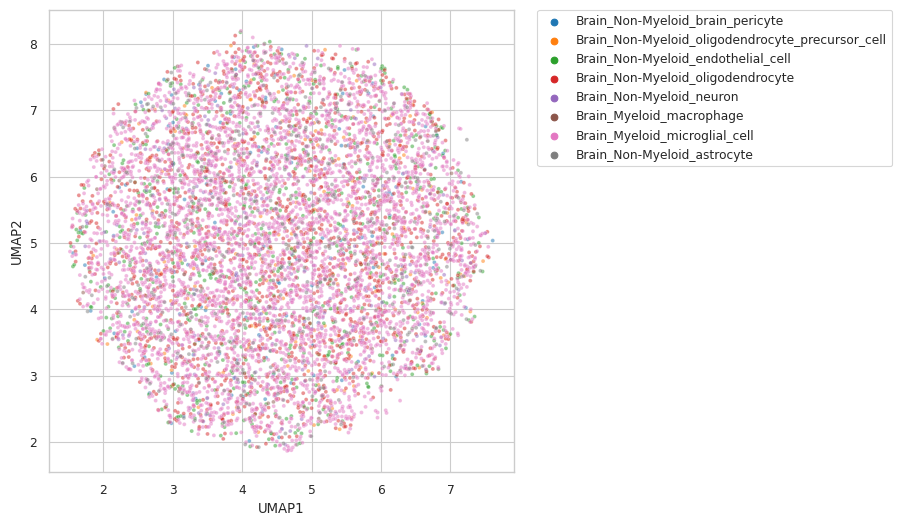

In [451]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(data=umap_embedding_df, x='UMAP1', y='UMAP2', hue='cell_type', palette='tab10', s=8, alpha=0.5)

# put legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [452]:
# calcualte silhouette score
from sklearn.metrics import silhouette_score
cell_types = cell_ids_conversion["cell_type"].values
silhouette_score(umap_embedding, cell_types)

-0.033615664

In [453]:
# calcualte Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(umap_embedding, cell_types)

72.59268928185534

In [454]:
model

VAE(
  (encoder): Encoder(
    (body): Sequential(
      (0): Linear(in_features=15926, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.0, inplace=False)
    )
    (linear_means): Linear(in_features=64, out_features=14, bias=True)
    (linear_log_var): Linear(in_features=64, out_features=14, bias=True)
  )
  (decoder): Decoder(
    (body): Sequential(
      (0): Linear(in_features=14, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.0, inplace=False)
      (3): Linear(in_features=64, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.0, inplace=False)
      (6): Linear(in_features=128, out_features=15926, bias=True)
    )
  )
)

In [455]:
latent_variables

array([[-0.9236997 , -0.42475608, -2.6454139 , ...,  2.2652423 ,
         0.31099784, -0.1844436 ],
       [ 1.2871596 ,  1.181762  , -0.12726519, ..., -0.00768633,
         1.8968601 ,  0.6871865 ],
       [-0.07700723, -0.83697   ,  1.3526672 , ...,  1.5152733 ,
         0.01378165,  0.45287693],
       ...,
       [-1.7966344 , -0.32941285,  0.29948384, ..., -0.558973  ,
         1.2762722 ,  0.28987053],
       [ 1.0868886 ,  1.2823263 , -0.8600173 , ..., -0.06737901,
        -2.4565442 , -1.6845443 ],
       [ 0.26369882, -0.6840762 ,  0.17059791, ..., -0.42119986,
        -0.00330505,  0.5791123 ]], dtype=float32)

### Evaluate latent variables 

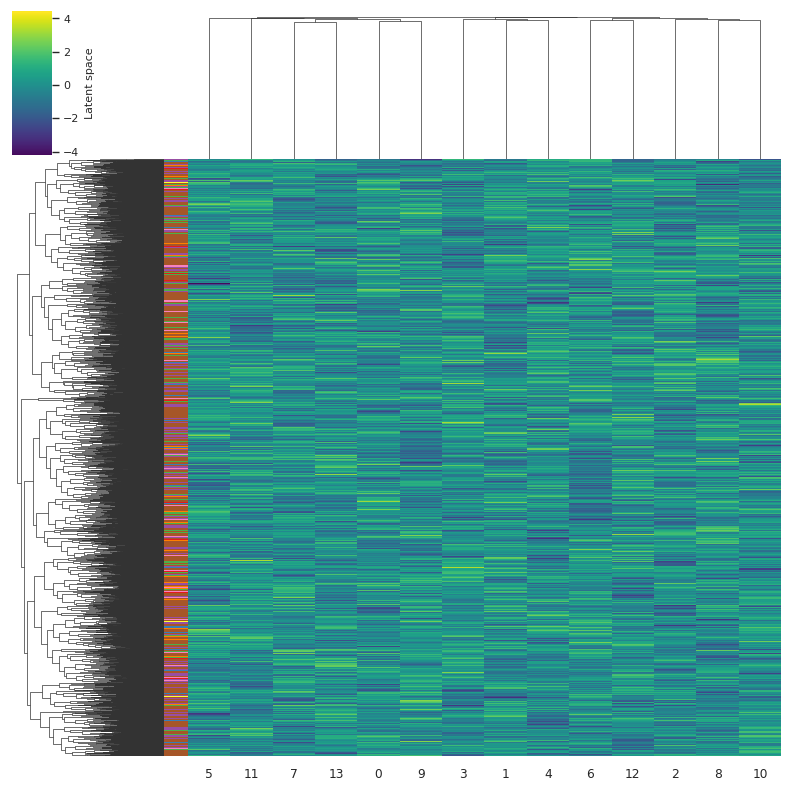

In [456]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=latent_variables,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Latent space'} 
    )
cluster.cax.set_ylabel('Latent space', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [457]:
Z_DIM

14

In [458]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = latent_variables[cell_type_indices].mean(axis=0)

# make a dataframe

cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
K = Z_DIM
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df

,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13
Brain_Non-Myeloid_brain_pericyte,-0.064709,-0.008378,-0.083348,0.061422,-0.040681,0.010867,-0.155451,-0.190510,-0.006298,-0.030570,0.111789,0.020935,0.051462,-0.079922
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.083378,0.031678,-0.066977,0.025488,-0.016782,-0.074020,0.178480,-0.073671,0.063530,-0.036945,0.055346,-0.001656,0.036464,-0.011572
Brain_Non-Myeloid_endothelial_cell,-0.050108,0.054764,0.035651,0.057442,0.024976,0.020556,-0.008069,-0.117053,-0.059880,0.050310,-0.052410,0.033855,-0.007814,0.031382
Brain_Non-Myeloid_oligodendrocyte,0.052442,0.011290,0.000245,0.009706,0.011990,-0.010773,-0.016408,-0.003558,-0.040231,-0.005801,-0.007980,0.044643,0.023515,0.027573
Brain_Non-Myeloid_neuron,-0.004986,0.089445,0.006004,-0.014391,0.064594,-0.005053,0.014955,0.037563,0.017507,-0.092572,0.023534,0.018427,-0.092312,-0.092948
Brain_Myeloid_macrophage,0.052127,0.058577,0.015088,0.030036,0.052475,-0.171752,0.009374,-0.043241,0.227520,-0.116844,-0.049786,-0.207666,0.027795,0.017910
Brain_Myeloid_microglial_cell,-0.005762,-0.001913,-0.009421,0.007316,0.009216,0.009764,0.001312,-0.011389,-0.028555,-0.009299,0.010638,0.009125,-0.013291,-0.028566
Brain_Non-Myeloid_astrocyte,-0.029865,-0.022986,-0.034539,-0.037558,-0.034675,0.015959,-0.021592,0.007459,0.067800,-0.006261,0.063354,-0.044617,0.013270,0.054939


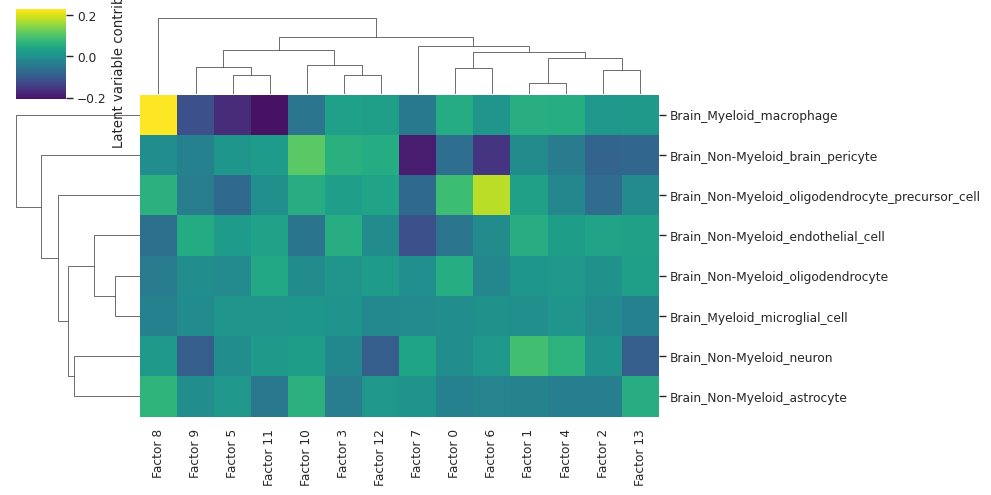

In [459]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 8},
    yticklabels=True,
    figsize=(10, 5),
    center=0,
    cbar_kws={'label': 'Latent variable contribution'} 
    )